这个文档是单云模型求双高斯速度

In [1]:
import sunpy
import sunpy.map
import numpy as np
from math import *
import astropy.units as u
from astropy.io import fits
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sunpy.coordinates import frames
import matplotlib.gridspec as gridspec
from scipy.interpolate import interp1d
from astropy.coordinates import SkyCoord
from matplotlib.patches import ConnectionPatch
import glob
from scipy.io import readsav
from scipy.ndimage import zoom
from scipy.special import wofz
from functools import partial

In [2]:
def voigt_single_cloud(lambda1, I_voigt, gamma_voigt, sigma_voigt,
                       I_cloud, mu_cloud, sigma_cloud, I_constant, S_l, I_0):

    z = (lambda1 + 1j * gamma_voigt) / (sigma_voigt * np.sqrt(2))
    voigt_component = np.real(wofz(z)) / (sigma_voigt * np.sqrt(2 * np.pi)) * I_voigt
    tau1 = I_cloud * np.exp(-0.5*((lambda1 - mu_cloud) / sigma_cloud) ** 2)
    cloud_component = (S_l - I_0) * (1 - np.exp(-tau1))
    return voigt_component + cloud_component + I_constant
# 双高斯 + Voigt + 常数
def voigt_double_cloud(lambda1, I_voigt, gamma_voigt, sigma_voigt,
                       I_cloud1, mu_cloud1, sigma_cloud1,
                       I_cloud2, mu_cloud2, sigma_cloud2, I_constant,S_l):
    z = (lambda1 + 1j * gamma_voigt) / (sigma_voigt * np.sqrt(2))
    voigt_component = np.real(wofz(z)) / (sigma_voigt * np.sqrt(2 * np.pi)) * I_voigt
    tau1 = I_cloud1 * np.exp(-((lambda1 - mu_cloud1) / sigma_cloud1) ** 2)
    cloud_component1 = S_l * np.exp(-tau1)
    tau2 = I_cloud2 * np.exp(-((lambda1 - mu_cloud2) / sigma_cloud2) ** 2)
    cloud_component2 = S_l * np.exp(-tau2)
    return voigt_component + cloud_component1 + cloud_component2 + I_constant


def voigt(lambda1, I_voigt, gamma_voigt, sigma_voigt):
    """
    Voigt 分量函数
    """
    z = (lambda1 + 1j * gamma_voigt) / (sigma_voigt * np.sqrt(2))
    voigt_component = np.real(wofz(z)) / (sigma_voigt * np.sqrt(2 * np.pi)) * I_voigt
    return voigt_component


def voigt_max_coefficient(gamma_voigt, sigma_voigt):
    """
    计算 Voigt 的最大系数，用于归一化
    """
    z_max = (1j * gamma_voigt) / (sigma_voigt * np.sqrt(2))
    return (sigma_voigt * np.sqrt(2 * np.pi)) / (np.real(wofz(z_max)))

In [3]:
dir=r'D:\Learning\PHD1st\magnetic_reconnecion\data\CHASE_Ha\RSM20240618T211711_0000_HA.fits'
rsm=fits.open(dir)
spectrum=rsm[1].data[:,795,1521]
lam = rsm[1].header['CRVAL3'] + np.arange(rsm[1].header['NAXIS3']) * rsm[1].header['CDELT3']

In [4]:
wavelength_point_list_ha_t0=lam
F_t0_l_TR=rsm[1].data[:,795,1521]
F_t0_l_TR_interpolated = interp1d(wavelength_point_list_ha_t0, F_t0_l_TR, kind='cubic', fill_value='extrapolate')(
        wavelength_point_list_ha_t0)

In [6]:
print(rsm[1].header['R_SUN'])

910.0


In [5]:
TR_width = 70
TR_height = 70
psr = 1.0436
r_fe=rsm[1].header['R_SUN']
f_t0_lcont_TR=float(interp1d(wavelength_point_list_ha_t0, F_t0_l_TR, kind='cubic', fill_value='extrapolate')(6568))
I_0 = F_t0_l_TR_interpolated * (2 * TR_width / psr + 1) * (2 * TR_height / psr + 1) / (
                f_t0_lcont_TR * (2 * r_fe + 1) ** 2)

In [7]:
ha_left_index=50
ha_right_index=100
def cloud(x, tau_0, lam_0, delta_lam, S_l):
        """
        云模型公式：
        I(λ) = S_l * exp(-tau(λ))
        tau(λ) = tau_0 * exp(-((λ - λ0) / delta_λ)^2)
        """
        tau = tau_0 * np.exp(-0.5 * ((x - lam_0) / delta_lam) ** 2)
        intensity = (S_l - I_0[ha_left_index:ha_right_index + 1]) * (1 - np.exp(-tau))

        return intensity

In [ ]:

# ========================
# 准备数据
# ========================

x_fit = lam[ha_left_index:ha_right_index + 1] - 6562.8 
y_fit = spectrum[ha_left_index:ha_right_index + 1]
# Voigt 分量初值与范围
gamma_voigt_initial = 0.5
gamma_voigt_min, gamma_voigt_max = 0.0, 7

sigma_voigt_initial = 0.5
sigma_voigt_min, sigma_voigt_max = 0.0, 7

I_voigt_initial = 1.0 * np.max(y_fit) * voigt_max_coefficient(gamma_voigt_initial, sigma_voigt_initial)
I_voigt_min = 0.0
I_voigt_max = 5.0 * np.max(y_fit) * voigt_max_coefficient(gamma_voigt_initial, sigma_voigt_initial)

# 双高斯分量参数
I_cloud1_initial, I_cloud1_min, I_cloud1_max = 0.5, 0.01, 10
mu_cloud1_initial, mu_cloud1_min, mu_cloud1_max = -0.3, -1.0, -0.05
sigma_cloud1_initial, sigma_cloud1_min, sigma_cloud1_max = 0.1, 0.01, 0.5

I_cloud2_initial, I_cloud2_min, I_cloud2_max = 0.5, 0.01, 10
mu_cloud2_initial, mu_cloud2_min, mu_cloud2_max = 0.3, 0.05, 1.0
sigma_cloud2_initial, sigma_cloud2_min, sigma_cloud2_max = 0.1, 0.01, 0.5

# 常数项
I_constant_initial, I_constant_min, I_constant_max = 0.0, -0.01, 0.01
S_l_initial,S_l_min,S_l_max=0.003,0.001,1.0
# ========================
# 拟合调用（双高斯）
# ========================
voigt_single_cloud1 = partial(voigt_single_cloud, I_0=I_0[ha_left_index:ha_right_index + 1])

popt, pcov = curve_fit(
    voigt_single_cloud1, x_fit, y_fit,
    p0=(I_voigt_initial, gamma_voigt_initial, sigma_voigt_initial,
        I_cloud1_initial, mu_cloud1_initial, sigma_cloud1_initial,
        I_constant_initial,S_l_initial),
    bounds=(
        [I_voigt_min, gamma_voigt_min, sigma_voigt_min,
         I_cloud1_min, mu_cloud1_min, sigma_cloud1_min,
         I_constant_min,S_l_min],
        [I_voigt_max, gamma_voigt_max, sigma_voigt_max,
         I_cloud1_max, mu_cloud1_max, sigma_cloud1_max,
         I_constant_max,S_l_max]
    )
)

# popt, pcov = curve_fit(
#     voigt_double_cloud, x_fit, y_fit,
#     p0=(I_voigt_initial, gamma_voigt_initial, sigma_voigt_initial,
#         I_cloud1_initial, mu_cloud1_initial, sigma_cloud1_initial,
#         I_cloud2_initial, mu_cloud2_initial, sigma_cloud2_initial,
#         I_constant_initial,S_l_initial),
#     bounds=(
#         [I_voigt_min, gamma_voigt_min, sigma_voigt_min,
#          I_cloud1_min, mu_cloud1_min, sigma_cloud1_min,
#          I_cloud2_min, mu_cloud2_min, sigma_cloud2_min,
#          I_constant_min,S_l_min],
#         [I_voigt_max, gamma_voigt_max, sigma_voigt_max,
#          I_cloud1_max, mu_cloud1_max, sigma_cloud1_max,
#          I_cloud2_max, mu_cloud2_max, sigma_cloud2_max,
#          I_constant_max,S_l_max]
#     )
# )
# ========================
# 提取参数
# ========================
I_voigt_fit, gamma_voigt_fit, sigma_voigt_fit, \
I_cloud1_fit, mu_cloud1_fit, sigma_cloud1_fit, \
I_constant_fit,S_l_fit = popt

# I_voigt_fit, gamma_voigt_fit, sigma_voigt_fit, \
# I_cloud1_fit, mu_cloud1_fit, sigma_cloud1_fit, \
# I_cloud2_fit, mu_cloud2_fit, sigma_cloud2_fit, \
# I_constant_fit,S_l_fit = popt

# ========================
# 转换为速度（km/s）
# ========================
c = 3e5  # 光速 km/s
v1 = c * mu_cloud1_fit / 6562.8
#v2 = c * mu_cloud2_fit / 6562.8

print(f"Velocity component 1 = {v1:.2f} km/s")
#print(f"Velocity component 2 = {v2:.2f} km/s")


Velocity component 1 = -2.29 km/s


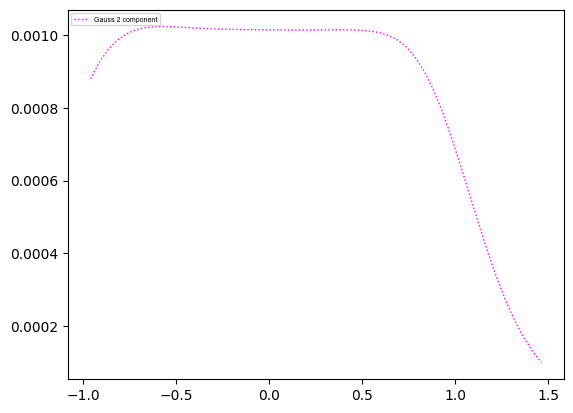

In [11]:
plt.plot(
            x_fit,
            cloud(x_fit, I_cloud1_fit, mu_cloud1_fit, sigma_cloud1_fit, S_l_fit),
            linestyle=':',
            linewidth=1,
            color='magenta',
            zorder=2.4,
            label='Gauss 2 component'
        )
# plt.plot(
#             x_fit,
#             voigt(x_fit, I_voigt_fit, gamma_voigt_fit, sigma_voigt_fit) + I_constant_fit,
#             linestyle='--',
#             linewidth=1,
#             color='darkorange',
#             zorder=2.2,
#             label='Voigt + Constant components')
plt.legend(loc='upper left', frameon=True, prop={'family': 'Arial', 'weight': 'normal', 'size': 5})

In [ ]:
def double_cloud(x,tau1,lam1,delta_lam1,tau2,lam2,delta_lam2,S_l,I0):
    tau11=tau1*np.exp(-0.5*((x-lam1)/delta_lam1)**2)
    tau22=tau2*np.exp(-0.5*((x-lam2)/delta_lam2)**2)
    tau=tau11+tau22
    intensity=

In [26]:
def double_gaussian(x, a1, x1, sigma1, a2, x2, sigma2,c):
    return (a1 * np.exp(-(x - x1)**2 / (sigma1**2)) +
            a2 * np.exp(-(x - x2)**2 / (sigma2**2)) + c)

In [27]:
a1_initial=-(max(y_fit)-min(y_fit))
sigma1_initial=0.1
x1_initial=-0.2
a2_initial=-(max(y_fit)-min(y_fit))
sigma2_initial=0.1
x2_initial=0.15
c_initial=max(y_fit)
initial_guess=[a1_initial,sigma1_initial,x1_initial,
               a2_initial,sigma2_initial,x2_initial,c_initial]
popt,pcov=curve_fit(double_gaussian,x_fit,y_fit,p0=initial_guess,maxfev=5000)
a1,sigma1,mu1,a2,sigma2,mu2,c2=popt
print(mu1*c/6562.8)
print(mu2*c/6562.8)

-24.526246666732966
24.485437808003695


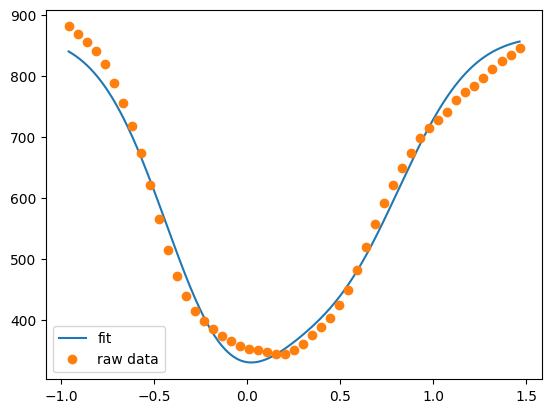

In [31]:
x11=np.linspace(min(x_fit),max(x_fit),1000)
y11=double_gaussian(x11,*popt)
plt.plot(x11,y11,label='fit')
plt.plot(x_fit,y_fit,'o',label='raw data')
plt.legend()

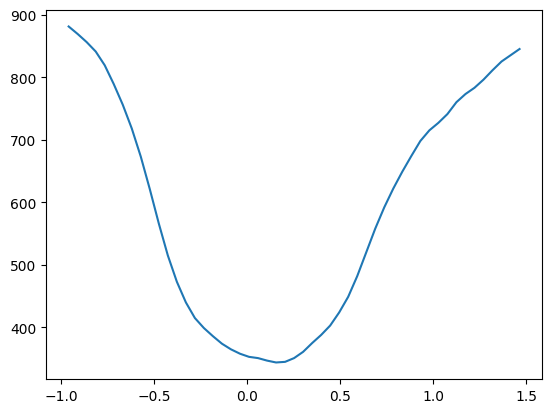

In [6]:
plt.plot(x_fit,y_fit)